# Filtering Problem

Suposse the state $X_t \in \R^n$ at time t of a system is given by a stocvhastic differential equation
$$ dX_t = b(t,X_t)dt + \sigma(t,X_t)dU_t, \quad X(0) = X_0, $$
where $b:\R^{n+1} \to \R^n$, $\sigma:\R^{n+1} \to \R^{n\times p}$ and $U_t$ is a p-dimensional Browniam motion. 

However, what we measure as a result of the disturbances is a state $Z_t \in \R^m$ satisfying another stocvhastic differential equation
$$ dZ_t = c(t,X_t)dt + \gamma(t,X_t)dV_t,  \quad Z(0) = Z_0,$$
where $c:\R^{n+1} \to \R^m$, $\gamma:\R^{n+1} \to \R^{m\times q}$ and $V_t$ is a q-dimensional Browniam motion. 

In this situation, the filtering problem consists of, given the observations $Z_s$ for $0 \leq s \leq t$, we want to find the best aproximation of $X_t$ at time t (\hat{X}_t) in the following sense:
$$ \begin{cases}
    \hat{X}_t(\cdot) \text{ is } \mathcal{C_t} \text { measurable, where } \mathcal{C_t} \text{ is the } \sigma\text{-algebra generated by } \{ Z_s, 0 \leq s \leq t\} \\
    E\left[ \left| X_t - \hat{X}_t \right|^2 \right] =  \inf\left\{ E\left[ \left| X_t - Y \right|^2 \right], \; Y \in L^2(P), \; Y \text{ is }\mathcal{C}_t \text{ measurable} \right\} \; \forall t >0
\end{cases}$$
where we denote by $(\Omega, \mathcal{F}, P)$ the probability space where the Browniam motion $(U_t, V_t)$


## The 1-dimensional Linear Filtering Problem

**Theorem: The 1-dimensional Kalman-Bucy filter**

*The solution $\widehat{X}_t$ of the 1-dimensional linear filtering problem*

$$
\begin{aligned}
&\text{(linear system)} & dX_t &= F(t)X_t dt + C(t)dU_t; \quad & F(t), C(t) &\in \mathbf{R}   \\
&\text{(linear observations)} & dZ_t &= G(t)X_t dt + D(t)dV_t; \quad & G(t), D(t) &\in \mathbf{R} \\
\end{aligned}
$$

*(with the conditions: F,C,G,D are bounded on bounded intervals with D away from zero, Z_0 = 0 and X_0 is independent of $(U_t,V_t)$ and is normally distributed) satisfies the stochastic differential equation*

$$d\widehat{X}_t = \left( F(t) - \frac{G^2(t)S(t)}{D^2(t)} \right) \widehat{X}_t dt + \frac{G(t)S(t)}{D^2(t)} dZ_t ; \quad \widehat{X}_0 = E[X_0] $$

*where* $S(t) = E[(X_t - \widehat{X}_t)^2]$ *satisfies the (deterministic) Riccati equation*

$$\frac{dS}{dt} = 2F(t)S(t) - \frac{G^2(t)}{D^2(t)}S^2(t) + C^2(t), \quad S(0) = E[(X_0 - E[X_0])^2]. $$

### Application to the Ornstein-Uhlenbeck process

Imagine we are tracking an autonomous underwater vehicle (or a particle).

The Dynamics (The System): The vehicle experiences a frictional force proportional to its position that tends to return it to its starting point (mean reversion), but it also undergoes random impacts from underwater currents.
$$dX_t = -\lambda X_t dt + \sigma dU_t,$$
where $\lambda > 0$ is the coefficient of friction or rate of return to the mean and $\sigma > 0$ is the magnitude of the noise.

The Measurement (The Observations): We have an acoustic sonar sensor that measures the vehicle’s position, but the sensor has constant white noise in the background due to the ocean environment.
$$dZ_t = X_t dt + \gamma dV_t$$
where $\gamma > 0$ is the magnitude of the sensor`s noise.

We assume that we have no idea where exactly the vehicle started, but we suppose that it began at an estimated average position $\hat{X}_0 = 0$ with a large initial uncertainty $S_0$

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import BarycentricInterpolator
from scipy.interpolate import interp1d

<>:57: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:57: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\pablo\AppData\Local\Temp\ipykernel_6632\3863115298.py:57: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.plot(t, hatX, label='Filtered estimate $\hat{X}_t$', color='green')


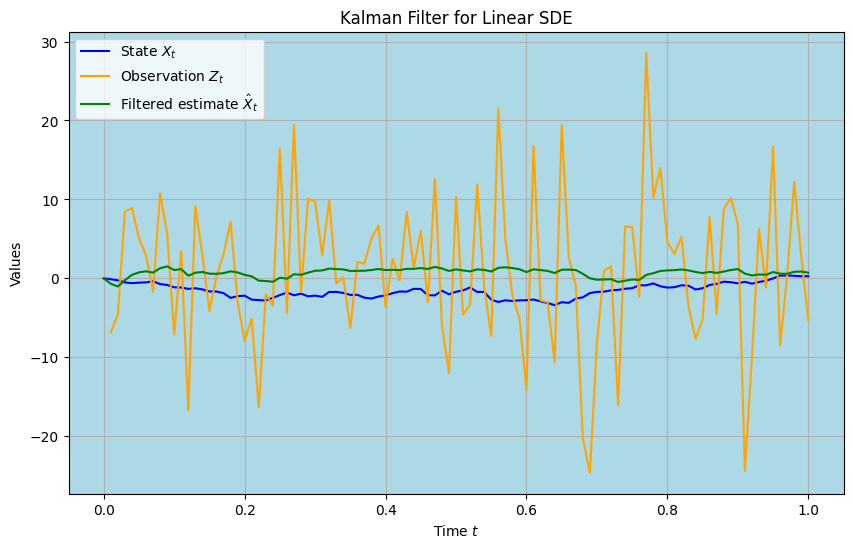

Mean squared error: 6.34827670967691


In [45]:
# Euler-Maruyama method for simulating SDEs
def euler_maruyama(b, sigma, T, Z, N, W = None):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    X = np.zeros(N + 1)
    X[0] = Z

    if W is None:
        W = np.zeros(N + 1)
        W[1:] = np.random.normal(0, np.sqrt(dt), N)
        W = np.cumsum(W)
    
    for n in range(N):
        tn = t[n]
        Xn = X[n]
        dW = W[n+1] - W[n]
        X[n+1] = Xn + b(tn, Xn) * dt + sigma(tn, Xn) * dW
    return t, X

# The deterministic Riccati equation
def Riccati(t,S, F, C, G, D):
    return 2*F(t)*S - (G(t)*S/D(t))**2 + C(t)**2

# Data of the problem
lambda_ = 1.0
F = lambda t: -lambda_
sigma_ = 3.0
C = lambda t: sigma_
G = lambda t: 1.0
gamma_ = 1.0
D = lambda t: gamma_
X_0 = 0.0
S_0 = 10.0
T = 1.0

# Simualte the state X_t
t,X = euler_maruyama(lambda t,x: F(t)*x, lambda t,x: C(t), T, X_0, 100)

# Simulate the observation Z_t
interpolator = interp1d(t, X, kind='linear')
_,Z = euler_maruyama(lambda t,x: G(t)*interpolator(t), lambda t,x: D(t), T, 0.0, 100)

# Calculate the solution of the Riccati equation
sol = solve_ivp(lambda t,S: Riccati(t, S, F, C, G, D), [0, T], [S_0], t_eval=t)
S = sol.y[0]
S = interp1d(t, S, kind='linear')

# The Kalman filter equations
b = lambda t,x: (F(t) - (G(t)**2 * S(t) / (D(t)**2))) * x
sigma = lambda t,x: G(t)*S(t)/(D(t)**2)
_,hatX = euler_maruyama(b, sigma, T, X_0, 100, W=Z)

plt.figure(figsize=(10, 6))
plt.plot(t, X, label='State $X_t$', color='blue')
dt = t[1] - t[0]
plt.plot(t[1:], np.diff(Z)/dt, label='Observation $Z_t$', color='orange')
plt.plot(t, hatX, label='Filtered estimate $\hat{X}_t$', color='green')
plt.title('Kalman Filter for Linear SDE')
plt.xlabel('Time $t$')
plt.ylabel('Values')
plt.legend()
plt.grid()
plt.gca().set_facecolor('lightblue')
plt.show()

error = np.mean((X - hatX)**2)
print(f"Mean squared error: {error}")

## The Multidimensional Linear Filtering Problem

**Theorem: The Multi-Dimensional Kalman-Bucy Filter.**

The solution $\widehat{X}_t$ of the multi-dimensional linear filtering problem

$$\begin{align}
\text{(linear system)} \quad & dX_t = F(t)X_t dt + C(t)dU_t; \quad & F(t) \in \mathbf{R}^{n \times n}, C(t) \in \mathbf{R}^{n \times p} \\
\text{(linear observations)} \quad & dZ_t = G(t)X_t dt + D(t)dV_t; \quad & G(t) \in \mathbf{R}^{m \times n}, D(t) \in \mathbf{R}^{m \times r}
\end{align}$$

satisfies the stochastic differential equation

$$d\widehat{X}_t = \left(F - SG^T(DD^T)^{-1}G \right)\widehat{X}_t dt + SG^T(DD^T)^{-1}dZ_t ; \quad \widehat{X}_0 = E[X_0] $$

where $S(t) := E[(X_t - \widehat{X}_t)(X_t - \widehat{X}_t)^T] \in \mathbf{R}^{n \times n}$ satisfies the matrix Riccati equation

$$\begin{align}
\frac{dS}{dt} &= FS + SF^T - SG^T(DD^T)^{-1}GS + CC^T ; \\
S(0) &= E[(X_0 - E[X_0])(X_0 - E[X_0])^T]. \tag{6.3.4}
\end{align}$$

The condition on $D(t) \in \mathbf{R}^{m \times r}$ is now that $D(t)D(t)^T$ is invertible for all $t$ and that $(D(t)D(t)^T)^{-1}$ is bounded on every bounded $t$-interval.

### Mathematical Formulation of the 3D Missile Tracking Problem

We aim to estimate the real-time trajectory of a ballistic missile flying in a 3D space using noisy radar measurements. We model this as a continuous-time linear filtering problem (Kalman-Bucy filter).

1. The State Vector
The state of the missile at time $t$ is described by a 6-dimensional vector containing its 3D position and 3D velocity:


$$X_t = \begin{bmatrix} x & y & z & v_x & v_y & v_z \end{bmatrix}^T \in \mathbb{R}^6$$

2. System Dynamics (The Physical Model)
The evolution of the missile is governed by the following Stochastic Differential Equation (SDE):


$$dX_t = (F X_t + u)dt + C dU_t$$


Where:

$F \in \mathbb{R}^{6 \times 6}$ is the state transition matrix that links velocity to the rate of change of position ($\frac{d\mathbf{p}}{dt} = \mathbf{v}$).

$u = \begin{bmatrix} 0 & 0 & 0 & 0 & 0 & -g \end{bmatrix}^T$ is a deterministic drift term accounting for Earth's gravity ($g \approx 9.81 \, \text{m/s}^2$).

$C \in \mathbb{R}^{6 \times 3}$ is the system noise matrix. We assume that wind turbulence only directly affects the velocity components (acceleration noise).

$dU_t$ represents the increments of a 3-dimensional standard Brownian motion modeling the unpredictable wind gusts.

3. Observation Dynamics (The Radar)
A ground-based radar continuously tracks the missile. However, the radar can only measure the 3D position (not the velocity), and its signal is corrupted by atmospheric and thermal white noise. We model the integrated observation process $Z_t \in \mathbb{R}^3$ as:


$$dZ_t = G X_t dt + D dV_t$$


Where:

$G \in \mathbb{R}^{3 \times 6}$ is the observation matrix that projects the 6D state space onto the 3D position space (extracting only $x, y, z$).

$D \in \mathbb{R}^{3 \times 3}$ is the observation noise matrix (sensor covariance), determined by the radar's inaccuracy ($\sigma_{radar}$).

$dV_t$ represents the increments of an independent 3-dimensional standard Brownian motion modeling the sensor noise.

Objective:
Given the continuous stream of noisy radar observations up to time $t$ (the filtration $\mathcal{G}_t$), we want to compute the optimal minimum mean square error (MMSE) estimate of the missile's true state, given by $\widehat{X}_t = E[X_t | \mathcal{G}_t]$, using the continuous multi-dimensional Kalman-Bucy filter.

Resolviendo Ecuación de Riccati...
Simulando trayectoria y filtro...


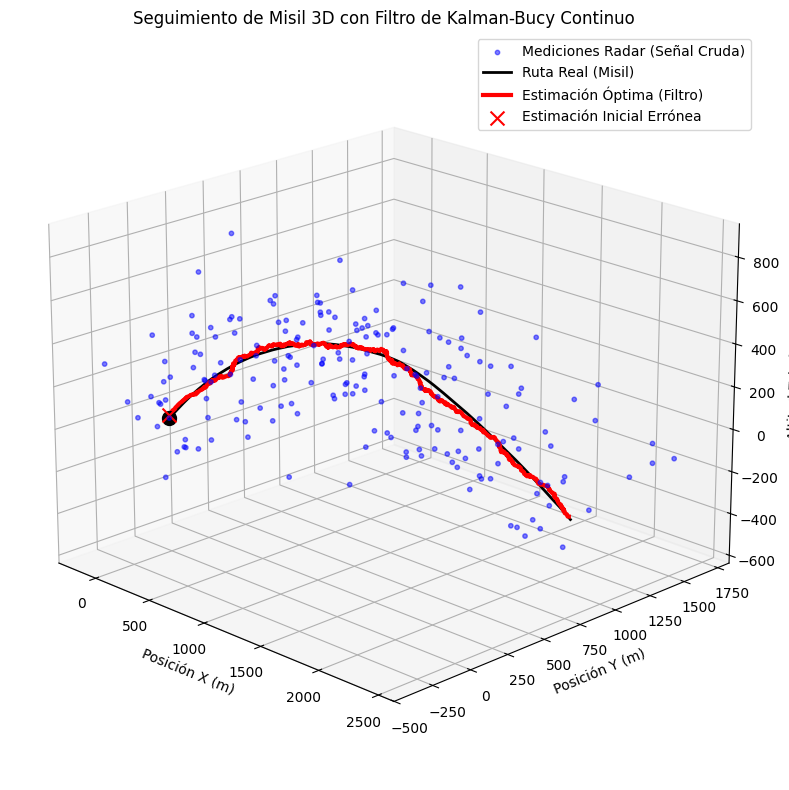

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ==========================================
# 1. PARÁMETROS DEL MODELO FÍSICO
# ==========================================
T = 20.0          # Tiempo total de vuelo (segundos)
N_steps = 1000    # Número de pasos de integración
dt = T / N_steps
t = np.linspace(0, T, N_steps + 1)

# Matrices del sistema continuo dX = (F*X + u)dt + C*dU
# Estado: [x, y, z, vx, vy, vz]
F = np.zeros((6, 6))
F[0, 3] = 1.0  # dx/dt = vx
F[1, 4] = 1.0  # dy/dt = vy
F[2, 5] = 1.0  # dz/dt = vz

# Gravedad (término determinista)
u = np.array([0, 0, 0, 0, 0, -9.81])

# Ruido del sistema (turbulencia del viento afecta solo a la velocidad)
sigma_viento = 5.0
C = np.zeros((6, 3))
C[3:, :] = sigma_viento * np.eye(3)

# Matrices de observación dZ = G*X dt + D*dV
# El radar solo mide posiciones (x, y, z), no velocidades
G = np.zeros((3, 6))
G[0, 0] = 1.0
G[1, 1] = 1.0
G[2, 2] = 1.0

# Ruido del sensor del radar
sigma_radar = 30.0
D = sigma_radar * np.eye(3)
D_inv_sq = np.linalg.inv(D @ D.T) # (D * D^T)^-1

# Condiciones iniciales
X_0 = np.array([0.0, 0.0, 0.0, 100.0, 50.0, 100.0]) # Lanzamiento desde origen
X_hat_0 = np.array([10.0, -10.0, 20.0, 80.0, 60.0, 90.0]) # Estimación inicial errónea
S_0 = 100.0 * np.eye(6) # Gran incertidumbre inicial

# ==========================================
# 2. ECUACIÓN DE RICCATI MATRICIAL
# ==========================================
def riccati_ode(t, S_flat):
    # Reconstruir matriz 6x6
    S = S_flat.reshape((6, 6))
    
    # Ecuación de Riccati: dS/dt = F*S + S*F^T - S*G^T*(D*D^T)^-1*G*S + C*C^T
    term1 = F @ S
    term2 = S @ F.T
    term3 = S @ G.T @ D_inv_sq @ G @ S
    term4 = C @ C.T
    
    dSdt = term1 + term2 - term3 + term4
    return dSdt.flatten() # Aplanar para solve_ivp

# Resolver Riccati hacia adelante en el tiempo
print("Resolviendo Ecuación de Riccati...")
sol = solve_ivp(riccati_ode, [0, T], S_0.flatten(), t_eval=t)

# Crear interpolador para la matriz de covarianza S(t)
# Usamos interpolación lineal componente por componente
S_t = interp1d(t, sol.y, axis=1, kind='linear')

# ==========================================
# 3. SIMULACIÓN ESTOCÁSTICA (Euler-Maruyama 3D)
# ==========================================
print("Simulando trayectoria y filtro...")
X = np.zeros((N_steps + 1, 6))
Z_dot = np.zeros((N_steps + 1, 3)) # Derivada de Z (señal cruda del radar)
X_hat = np.zeros((N_steps + 1, 6))

X[0] = X_0
X_hat[0] = X_hat_0

for n in range(N_steps):
    tn = t[n]
    
    # Ruidos independientes brownianos
    dU = np.sqrt(dt) * np.random.randn(3) # Turbulencia 3D
    dV = np.sqrt(dt) * np.random.randn(3) # Ruido Radar 3D
    
    # 1. Avance del Estado Real (El misil en la realidad)
    dX = (F @ X[n] + u) * dt + C @ dU
    X[n+1] = X[n] + dX
    
    # 2. Señal Cruda del Radar (dZ/dt pseudo-continuo para visualización)
    # dZ = G*X*dt + D*dV  --> Señal percibida = dZ/dt
    Z_dot[n+1] = G @ X[n] + (D @ dV) / dt
    dZ = Z_dot[n+1] * dt
    
    # 3. Filtro Óptimo (Kalman-Bucy)
    S_actual = S_t(tn).reshape((6, 6))
    
    # Ganancia de Kalman: K(t) = S(t) * G^T * (D*D^T)^-1
    K = S_actual @ G.T @ D_inv_sq
    
    # Innovación: dN = dZ - G * X_hat * dt
    dN = dZ - (G @ X_hat[n]) * dt
    
    # Avance de la estimación
    dX_hat = (F @ X_hat[n] + u) * dt + K @ dN
    X_hat[n+1] = X_hat[n] + dX_hat

# ==========================================
# 4. VISUALIZACIÓN 3D
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Extraer coordenadas de posición
x_real, y_real, z_real = X[:, 0], X[:, 1], X[:, 2]
x_radar, y_radar, z_radar = Z_dot[:, 0], Z_dot[:, 1], Z_dot[:, 2]
x_filt, y_filt, z_filt = X_hat[:, 0], X_hat[:, 1], X_hat[:, 2]

# Dibujar Radar (Puntos dispersos con ruido masivo)
ax.scatter(x_radar[::5], y_radar[::5], z_radar[::5], 
           c='blue', s=10, alpha=0.5, label='Mediciones Radar (Señal Cruda)')

# Dibujar Ruta Real
ax.plot(x_real, y_real, z_real, 
        color='black', linewidth=2, label='Ruta Real (Misil)')

# Dibujar Ruta Filtrada
ax.plot(x_filt, y_filt, z_filt, 
        color='red', linewidth=3, linestyle='-', label='Estimación Óptima (Filtro)')

# Punto de inicio
ax.scatter(X_0[0], X_0[1], X_0[2], color='black', s=100, marker='o')
ax.scatter(X_hat_0[0], X_hat_0[1], X_hat_0[2], color='red', s=100, marker='x', label='Estimación Inicial Errónea')

ax.set_title('Seguimiento de Misil 3D con Filtro de Kalman-Bucy Continuo')
ax.set_xlabel('Posición X (m)')
ax.set_ylabel('Posición Y (m)')
ax.set_zlabel('Altitud Z (m)')
ax.legend()

# Ajustar ángulo de visión
ax.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.show()